In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from datetime import datetime
import subprocess
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, clone_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from keras_tuner import HyperModel, BayesianOptimization
import random
import os
import json
import pickle

In [15]:
# ==================== SET FULL DETERMINISM ====================
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

In [16]:
# ========== OPSI DETERMINISME TINGGI (CPU ONLY) ==========
use_high_determinism = True
if use_high_determinism:
    try:
        tf.config.set_visible_devices([], 'GPU')
    except Exception:
        pass
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print("⚠️ Mode determinisme tinggi diaktifkan - Menggunakan CPU hanya")

⚠️ Mode determinisme tinggi diaktifkan - Menggunakan CPU hanya


In [17]:
# ==================== KONFIGURASI ====================
ticker = "AAPL"
lookback = 5
epsilon = 1e-6

base_path = "saved_models_lstm"
os.makedirs(base_path, exist_ok=True)

finetuned_dir = os.path.join(base_path, "finetuned_per_period")
os.makedirs(finetuned_dir, exist_ok=True)

sentiment_folder = "saved_sentiment_scraping"
os.makedirs(sentiment_folder, exist_ok=True)

best_model_path = os.path.join(base_path, f"best_lstm_model_{ticker.lower()}.keras")
sentiment_path = os.path.join(sentiment_folder, f"sentiment_{ticker.lower()}.csv")

covid_periods = {
    'Sebelum COVID': ('2017-04-09', '2020-02-29'),
    'Selama COVID':   ('2020-03-01', '2022-12-31'),
    'Setelah COVID':  ('2023-01-01', '2025-09-15')
}

In [18]:
# ==================== DATA SAHAM ====================
raw_data_path = os.path.join(base_path, f"raw_stock_prices_{ticker.lower()}.csv")
if os.path.exists(raw_data_path):
    data = pd.read_csv(raw_data_path,
                       skiprows=3, header=None,
                       names=['Date','Close'],
                       parse_dates=['Date']).set_index('Date')
    data['Close'] = data['Close'].astype(float)
else:
    data = yf.download(ticker, start='2017-04-09', end='2025-09-16')[['Close']]
    data.to_csv(raw_data_path, header=True)

data_daily = data.resample('D').ffill().interpolate()

In [19]:
# ==================== SENTIMEN HARIAN ====================
if os.path.exists(sentiment_path):
    sentiment_df = pd.read_csv(sentiment_path, parse_dates=['Date'], index_col='Date')
else:
    print("⚠️ File sentimen tidak ditemukan, menjalankan scraping otomatis...")
    try:
        subprocess.run(
            ["jupyter", "nbconvert", "--to", "notebook", "--execute",
             "Scraping Sentiment.ipynb", "--output", "Scraping_Sentiment_Out.ipynb"],
            check=True
        )
        sentiment_df = pd.read_csv(sentiment_path, parse_dates=['Date'], index_col='Date')
    except Exception as e:
        raise RuntimeError(f"Gagal menjalankan Scraping Sentiment.ipynb: {e}")

data_daily['Sentiment']      = sentiment_df['Sentiment'].reindex(data_daily.index).fillna(0)
data_daily['Sentiment_Lag1'] = data_daily['Sentiment'].shift(1)

In [20]:
# ==================== FITUR TEKNIKAL ====================
for i in range(1, lookback+1):
    data_daily[f'lag_{i}'] = data_daily['Close'].shift(i)
data_daily['MA_5']         = data_daily['Close'].rolling(5).mean()
data_daily['MA_20']        = data_daily['Close'].rolling(20).mean()
data_daily['Return_1D']    = data_daily['Close'].pct_change()
data_daily['Volatility_5D']= data_daily['Return_1D'].rolling(5).std()

def compute_rsi(s, period=14):
    delta = s.diff()
    gain  = delta.where(delta>0,0).rolling(period).mean()
    loss  = (-delta.where(delta<0,0)).rolling(period).mean()
    rs    = gain/loss
    return 100 - (100/(1+rs))

data_daily['RSI_14']      = compute_rsi(data_daily['Close'])
data_daily['Momentum_5D'] = data_daily['Close'] - data_daily['Close'].shift(5)
data_daily['MA_5_20_ratio'] = data_daily['MA_5'] / (data_daily['MA_20'] + epsilon)
data_daily['RSI_MA5']       = data_daily['RSI_14'] / data_daily['MA_5']

data_daily.dropna(inplace=True)
processed_features_path = os.path.join(base_path, f"processed_features_{ticker.lower()}.csv")
data_daily.to_csv(processed_features_path)
print(f"💾 Data fitur yang diproses disimpan di {processed_features_path}")

💾 Data fitur yang diproses disimpan di saved_models_lstm\processed_features_aapl.csv


In [21]:
# ==================== FITUR & TARGET ====================
features = [
    'Sentiment_Lag1','MA_5','MA_20','Return_1D',
    'Volatility_5D','RSI_14','Momentum_5D',
    'MA_5_20_ratio','RSI_MA5'
] + [f'lag_{i}' for i in range(1, lookback+1)]
target = 'Close'

def create_dataset(arr):
    return arr[:,:-1], arr[:,-1]

def mape(y_true,y_pred):
    y = np.maximum(np.abs(y_true), epsilon)
    return np.mean(np.abs((y_true-y_pred)/y)) * 100

def evaluate(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2' : r2_score(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

def print_metrics(m):
    for k,v in m.items():
        suf = '%' if k=='MAPE' else ''
        print(f"{k}: {v:.4f}{suf}")

In [22]:
# ==================== DEFINISI MODEL LSTM ====================
class SimpleLSTMModel(HyperModel):
    def __init__(self, num_features):
        self.num_features = num_features

    def build(self, hp):
        model = Sequential()
        model.add(tf.keras.layers.Reshape((1, self.num_features),
                                          input_shape=(self.num_features,)))
        model.add(LSTM(
            units=hp.Int('lstm_units', 128, 256, step=32),
            return_sequences=False,
            activation='tanh'
        ))
        model.add(Dense(
            units=hp.Int('dense_units', 32, 64, step=16),
            activation='relu'
        ))
        model.add(Dense(1, activation='linear'))
        optimizer = Adam(
            learning_rate=hp.Float('lr', 1e-4, 1e-2, sampling='log')
        )
        model.compile(optimizer=optimizer, loss=Huber())
        return model

In [23]:
# ==================== TUNING & TRAINING ====================
print("\n=== Melatih / Memuat Model LSTM (Keseluruhan Data) ===")
scaler_full = MinMaxScaler()
scaled_all  = scaler_full.fit_transform(data_daily[features + [target]])
X_all, y_all = create_dataset(scaled_all)
split_idx    = int(len(X_all) * 0.8)
X_train_full = X_all[:split_idx]
y_train_full = y_all[:split_idx]

X_train_full_aug = X_train_full.copy()

best_hps_path = os.path.join(base_path, f"best_hyperparams_{ticker.lower()}.json")
if os.path.exists(best_model_path):
    best_model = load_model(best_model_path)
    if not os.path.exists(best_hps_path):
        lstm_layer = best_model.layers[1]
        dense_layer = best_model.layers[2]
        lr = best_model.optimizer.learning_rate.numpy()
        best_hps = {
            'lstm_units': lstm_layer.units,
            'dense_units': dense_layer.units,
            'lr': float(lr)
        }
        with open(best_hps_path, 'w') as jf:
            json.dump(best_hps, jf, indent=4)
else:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_full_aug, y_train_full, test_size=0.2, shuffle=False
    )
    lr_scheduler = LearningRateScheduler(lambda e: 0.001 * (0.9 ** (e // 20)))
    callbacks = [
        EarlyStopping(patience=30, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        lr_scheduler
    ]
    tuner = BayesianOptimization(
        SimpleLSTMModel(num_features=len(features)),
        objective='val_loss',
        max_trials=30,
        num_initial_points=10,
        directory=os.path.join(base_path, 'lstm_tuning'),
        project_name='aapl_lstm',
        seed=seed_value,
        overwrite=True
    )
    tuner.search(
        X_tr, y_tr,
        epochs=800,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )
    best_model = tuner.get_best_models(num_models=1)[0]
    best_hps   = tuner.get_best_hyperparameters()[0].values
    with open(best_hps_path, 'w') as jf:
        json.dump(best_hps, jf, indent=4)
    best_model.save(best_model_path)

print("💾 Menyimpan model asli sebelum fine-tuning...")
original_best_model = clone_model(best_model)
original_best_model.set_weights(best_model.get_weights())


=== Melatih / Memuat Model LSTM (Keseluruhan Data) ===
💾 Menyimpan model asli sebelum fine-tuning...


c:\Users\andil\Downloads\prediksi_saham\venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
# ==================== IN-SAMPLE PREDIKSI ====================
train_pred_scaled = best_model.predict(X_train_full)
train_pred_inv    = scaler_full.inverse_transform(
    np.hstack([X_train_full, train_pred_scaled])
)[:,-1]
y_train_inv = scaler_full.inverse_transform(
    np.hstack([X_train_full, y_train_full.reshape(-1,1)])
)[:,-1]
overall_metrics = evaluate(y_train_inv, train_pred_inv)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# ==================== EVALUASI PER PERIODE COVID ====================
results       = {}
metrics_dict  = {}
plots         = []
orig_model    = clone_model(best_model)
orig_model.set_weights(best_model.get_weights())


for period, (start, end) in covid_periods.items():
    print(f"\n🔨 Periode {period}")
    ...
    fig, ax = plt.subplots(figsize=(10,5), dpi=150)
    ax.plot(dates_test, ytest_inv, label='Aktual')
    ax.plot(dates_test, pred_inv, '--', label='Prediksi')
    ax.set_title(f'{period}')
    ax.legend(); ax.grid(True)
    fig.autofmt_xdate()
    plots.append(fig)


results['Keseluruhan']      = {'dates': data_daily.index[-len(y_train_inv):],
                              'actual': y_train_inv, 'pred': train_pred_inv}
metrics_dict['Keseluruhan'] = overall_metrics

fig_full, ax_full = plt.subplots(figsize=(12,6), dpi=150)
ax_full.plot(data_daily.index[-len(y_train_inv):], y_train_inv, label='Aktual')
ax_full.plot(data_daily.index[-len(y_train_inv):], train_pred_inv, '--', label='Prediksi')
ax_full.set_title('Keseluruhan')
ax_full.legend(); ax_full.grid(True)
plots.insert(0, fig_full)




🔨 Periode Sebelum COVID
💾 Fine-tuned model for Sebelum COVID saved to: saved_models_lstm\finetuned_per_period\finetuned_with_sentiment_sebelum_covid.keras
💾 Scaler for Sebelum COVID saved to: saved_models_lstm\finetuned_per_period\scaler_sebelum_covid.pkl
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

🔨 Periode Selama COVID
💾 Fine-tuned model for Selama COVID saved to: saved_models_lstm\finetuned_per_period\finetuned_with_sentiment_selama_covid.keras
💾 Scaler for Selama COVID saved to: saved_models_lstm\finetuned_per_period\scaler_selama_covid.pkl
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

🔨 Periode Setelah COVID
💾 Fine-tuned model for Setelah COVID saved to: saved_models_lstm\finetuned_per_period\finetuned_with_sentiment_setelah_covid.keras
💾 Scaler for Setelah COVID saved to: saved_models_lstm\finetuned_per_period\scaler_setelah_covid.pkl
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


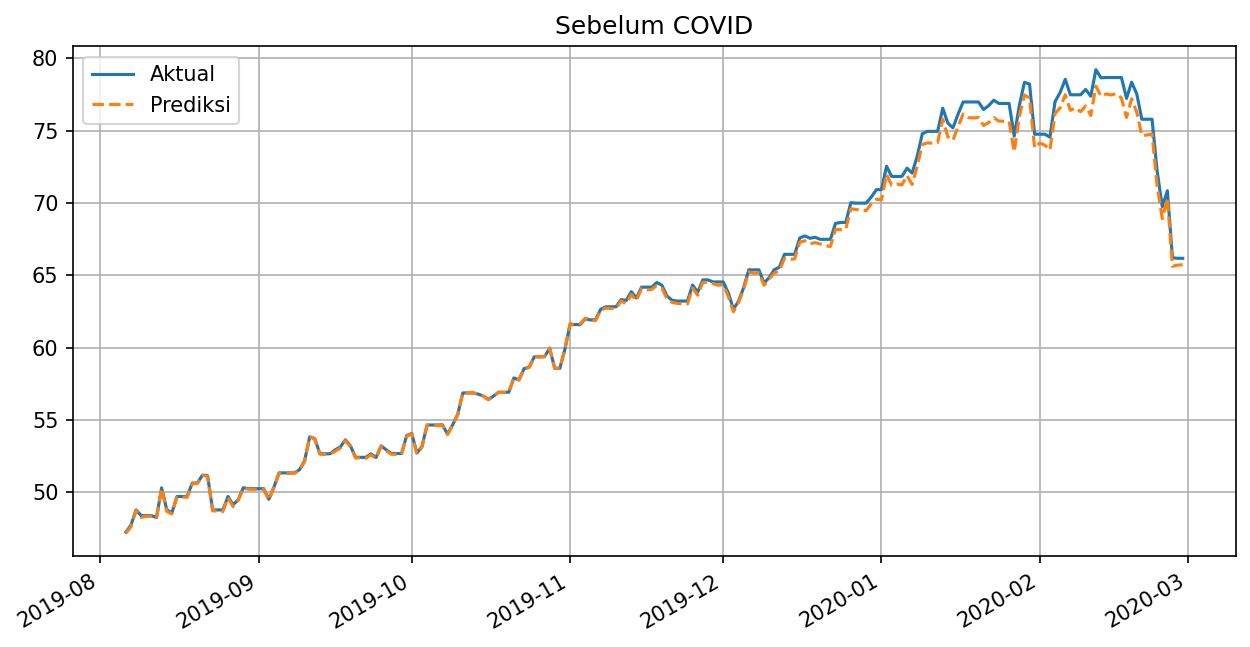

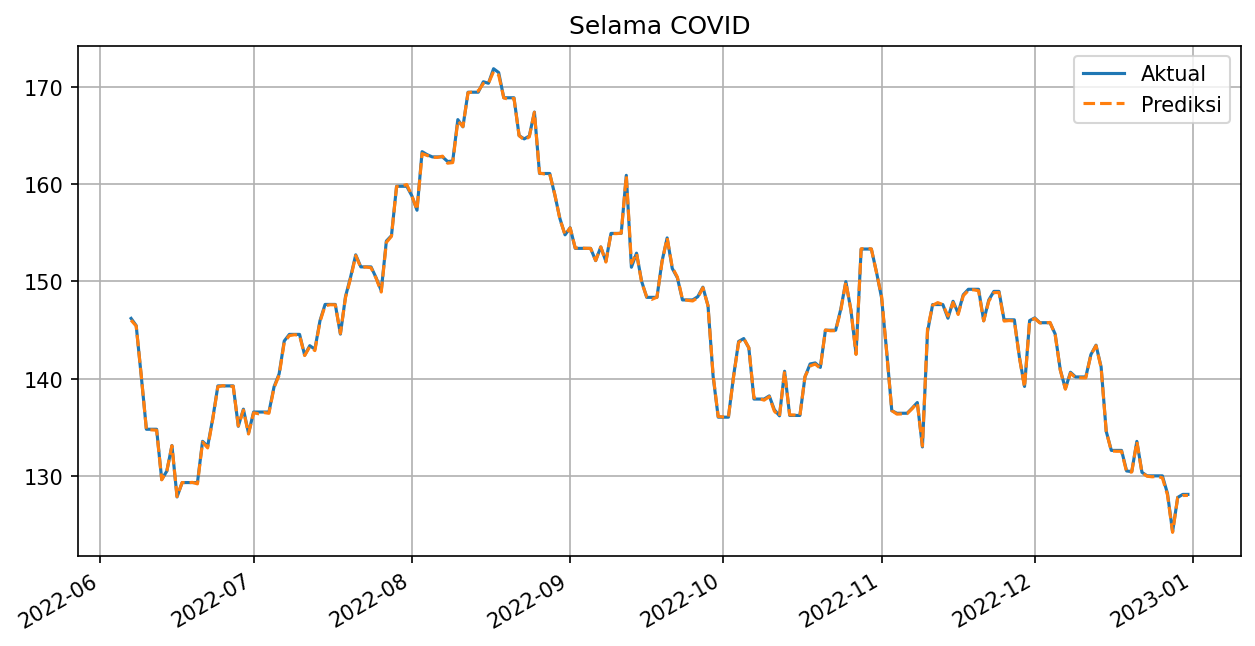

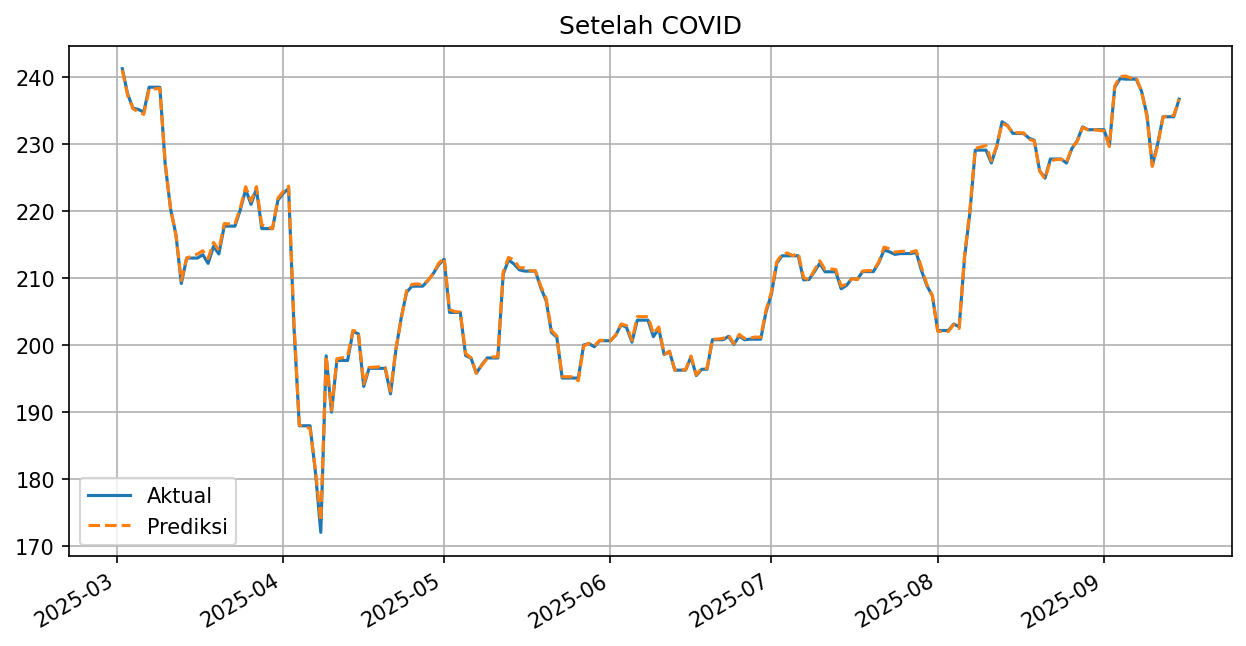

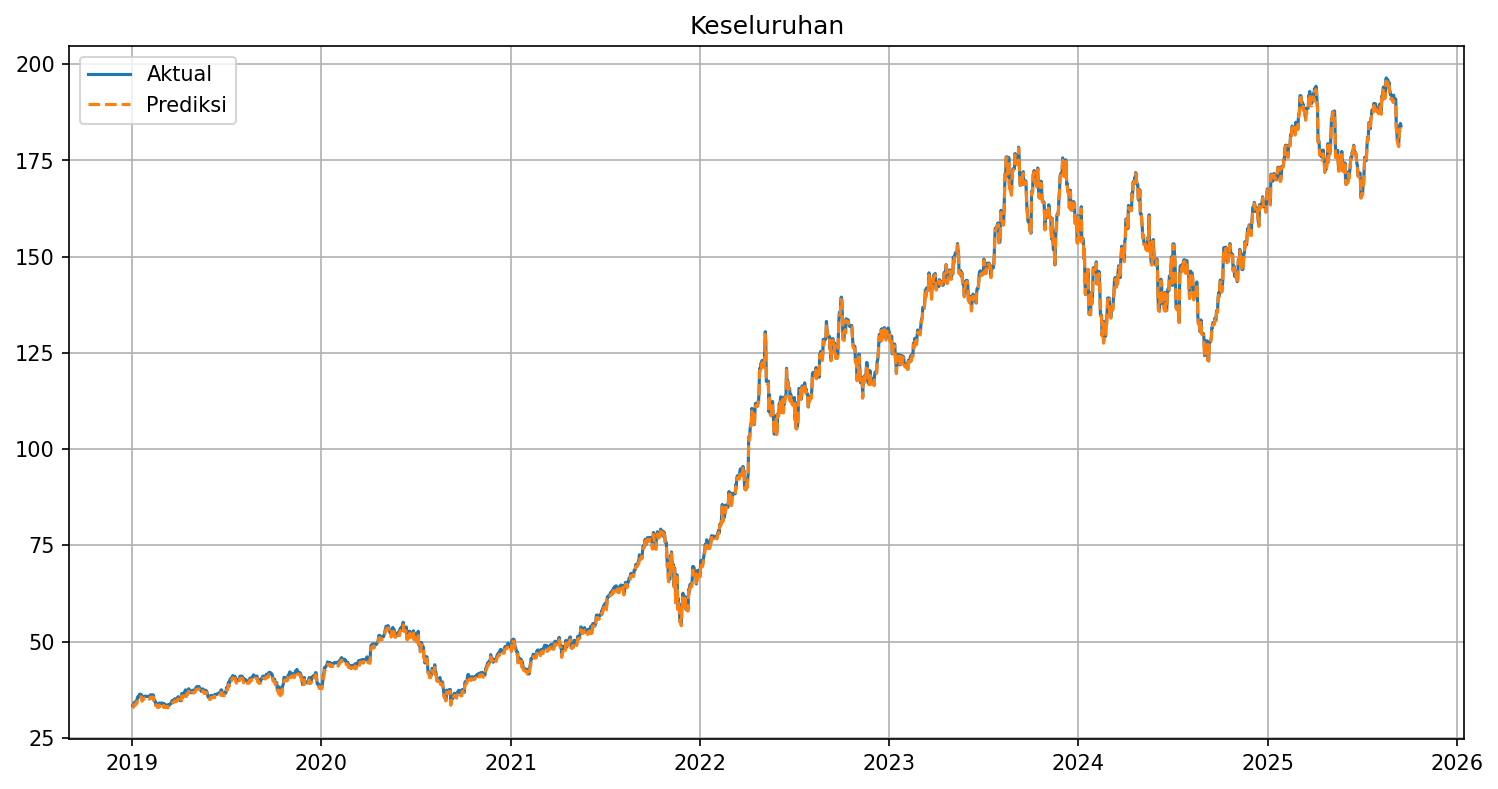

In [25]:
# ==================== EVALUASI PER PERIODE COVID ====================
results       = {}
metrics_dict  = {}
plots         = []
orig_model    = clone_model(best_model)
orig_model.set_weights(best_model.get_weights())

for period,(start,end) in covid_periods.items():
    print(f"\n🔨 Periode {period}")
    start_dt = pd.to_datetime(start)
    end_dt   = pd.to_datetime(end)
    dfp = data_daily[(data_daily.index >= start_dt) & (data_daily.index <= end_dt)].copy()

    if dfp.empty:
        print(f"⚠️ Periode {period} tidak memiliki data, lewati.")
        continue

    scaler_p = MinMaxScaler()
    scaled_p = scaler_p.fit_transform(dfp[features+[target]].values)
    Xp,yp = create_dataset(scaled_p)
    idx   = int(len(Xp)*0.8)
    Xtr, Xtest = Xp[:idx], Xp[idx:]
    ytr, ytest = yp[:idx], yp[idx:]

    model_copy = clone_model(orig_model)
    model_copy.set_weights(orig_model.get_weights())

    try:
        opt_config = best_model.optimizer.get_config()
        new_opt    = Adam.from_config(opt_config)
        new_opt.build(model_copy.trainable_variables)
        for nv, ov in zip(new_opt.variables, best_model.optimizer.variables):
            nv.assign(ov)
        model_copy.compile(optimizer=new_opt, loss=Huber(), run_eagerly=True)
    except Exception:
        model_copy.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber())

    model_copy.fit(Xtr, ytr, validation_split=0.2,
                   epochs=100, batch_size=16,
                   callbacks=[EarlyStopping(patience=15,restore_best_weights=True)],
                   verbose=0)

    finetuned_path = os.path.join(finetuned_dir, f"finetuned_with_sentiment_{period.replace(' ','_').lower()}.keras")
    scaler_path = os.path.join(finetuned_dir, f"scaler_{period.replace(' ','_').lower()}.pkl")
    try:
        model_copy.save(finetuned_path)
        print(f"💾 Fine-tuned model for {period} saved to: {finetuned_path}")
    except Exception as e:
        print(f"⚠️ Gagal menyimpan model fine-tuned untuk {period}: {e}")
    try:
        with open(scaler_path, 'wb') as f:
            pickle.dump(scaler_p, f)
        print(f"💾 Scaler for {period} saved to: {scaler_path}")
    except Exception as e:
        print(f"⚠️ Gagal menyimpan scaler untuk {period}: {e}")

    pred_scaled = model_copy.predict(Xtest)
    pred_inv    = scaler_p.inverse_transform(
        np.hstack([Xtest, pred_scaled])
    )[:,-1]
    ytest_inv   = scaler_p.inverse_transform(
        np.hstack([Xtest, ytest.reshape(-1,1)])
    )[:,-1]

    dates_test = dfp.index[-len(ytest_inv):]
    results[period]      = {'dates':dates_test,'actual':ytest_inv,'pred':pred_inv}
    metrics_dict[period] = evaluate(ytest_inv,pred_inv)

    fig,ax = plt.subplots(figsize=(10,5),dpi=150)
    ax.plot(dates_test, ytest_inv, label='Aktual')
    ax.plot(dates_test, pred_inv, '--', label='Prediksi')
    ax.set_title(f'{period}')
    ax.legend(); ax.grid(True)
    fig.autofmt_xdate()
    plots.append(fig)

# Tambahkan keseluruhan
results['Keseluruhan']      = {'dates': data_daily.index[-len(y_train_inv):],
                              'actual': y_train_inv, 'pred': train_pred_inv}
metrics_dict['Keseluruhan'] = overall_metrics
fig_full,ax_full = plt.subplots(figsize=(12,6),dpi=150)
ax_full.plot(data_daily.index[-len(y_train_inv):], y_train_inv, label='Aktual')
ax_full.plot(data_daily.index[-len(y_train_inv):], train_pred_inv, '--', label='Prediksi')
ax_full.set_title('Keseluruhan'); ax_full.legend(); ax_full.grid(True)
plots.insert(0, fig_full)

In [26]:
# ==================== CETAK METRIK ====================
print("\n📈 Metrics Keseluruhan:")
print_metrics(metrics_dict['Keseluruhan'])
for p in ['Sebelum COVID','Selama COVID','Setelah COVID']:
    if p in metrics_dict:
        print(f"\n📊 Metrics {p}:")
        print_metrics(metrics_dict[p])

# ==================== TAMPILKAN SEMUA PLOT ====================
for fig in plots:
    plt.show(fig)

# ==================== EKSPOR HASIL ====================
export_dir = "export_lstm_results"
os.makedirs(export_dir, exist_ok=True)
with open(os.path.join(export_dir,"all_metrics.json"),'w') as f:
    json.dump(metrics_dict,f,indent=4)

for key,data_dict in results.items():
    df_out = pd.DataFrame({
        'Date': pd.to_datetime(data_dict['dates']),
        'Actual': data_dict['actual'],
        'Predicted': data_dict['pred']
    })
    fname = key.lower().replace(' ','_')
    df_out.to_csv(os.path.join(export_dir,f"lstm_{fname}.csv"), index=False)
    with open(os.path.join(export_dir,f"metrics_lstm_{fname}.json"),'w') as f:
        json.dump(metrics_dict[key],f,indent=4)

print("\n✅ Semua hasil telah diekspor.")
print(f"💾 Fine-tuned models and scalers saved in: {finetuned_dir}")


📈 Metrics Keseluruhan:
MSE: 0.2460
MAE: 0.4654
R2: 0.9999
MAPE: 0.6974%

📊 Metrics Sebelum COVID:
MSE: 0.2954
MAE: 0.3570
R2: 0.9969
MAPE: 0.4943%

📊 Metrics Selama COVID:
MSE: 0.0096
MAE: 0.0770
R2: 0.9999
MAPE: 0.0528%

📊 Metrics Setelah COVID:
MSE: 0.0927
MAE: 0.2377
R2: 0.9995
MAPE: 0.1132%

✅ Semua hasil telah diekspor.
💾 Fine-tuned models and scalers saved in: saved_models_lstm\finetuned_per_period
